# 📊 Análisis de Licitaciones Electrónicas Europeas (TED 2018–2023)
**Fuente:** Tenders Electronic Daily (TED) — Diario Oficial de la UE  
> Este notebook carga el dataset desde Kaggle, realiza una exploración completa, limpieza y visualizaciones avanzadas.

## 0. 🔧 Instalación y carga del dataset

In [1]:
# Instalar dependencias
!pip install matplotlib seaborn plotly pandas numpy -q


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Estilo global
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor': '#1a1d2e',
    'axes.edgecolor': '#3a3f5c',
    'axes.labelcolor': '#e0e0e0',
    'xtick.color': '#aaaaaa',
    'ytick.color': '#aaaaaa',
    'text.color': '#e0e0e0',
    'grid.color': '#2a2d3e',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.titleweight': 'bold'
})

PALETTE = ['#4cc9f0', '#f72585', '#7209b7', '#3a0ca3', '#4361ee', '#4895ef', '#560bad']

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


In [3]:
# ── Carga del CSV local ──────────────────────────────────────────────────────
# Opción A: misma carpeta que el notebook
CSV_PATH = 'export_CAN_2023_2018.csv'

# Opción B: sube el archivo manualmente en Colab
# from google.colab import files
# uploaded = files.upload()          # selecciona export_CAN_2023_2018.csv
# CSV_PATH = list(uploaded.keys())[0]

# ─────────────────────────────────────────────────────────────────────────────
for enc in ['utf-8', 'latin-1', 'cp1252']:
    try:
        df = pd.read_csv(CSV_PATH, low_memory=False, encoding=enc)
        print(f'✅ Cargado con encoding {enc}')
        break
    except UnicodeDecodeError:
        print(f'⚠️  Encoding {enc} falló, probando siguiente...')

size_mb = os.path.getsize(CSV_PATH) / (1024 * 1024)
print(f'📄 Archivo: {CSV_PATH}  ({size_mb:.1f} MB)')
print(f'🗃️  Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas')

✅ Cargado con encoding utf-8
📄 Archivo: export_CAN_2023_2018.csv  (3822.4 MB)
🗃️  Dimensiones: 6,198,063 filas × 75 columnas


## 1. 🔍 Exploración inicial

In [4]:
# Vista general
print('=== PRIMERAS FILAS ===')
display(df.head(3))

print('\n=== TIPOS DE DATOS ===')
print(df.dtypes.to_string())

print('\n=== ESTADÍSTICAS DESCRIPTIVAS (numéricas) ===')
display(df.describe())

=== PRIMERAS FILAS ===


,ID_NOTICE_CAN,TED_NOTICE_URL,YEAR,ID_TYPE,DT_DISPATCH,XSD_VERSION,CANCELLED,CORRECTIONS,B_MULTIPLE_CAE,CAE_NAME,...,NUMBER_OFFERS,NUMBER_TENDERS_SME,NUMBER_TENDERS_OTHER_EU,NUMBER_TENDERS_NON_EU,NUMBER_OFFERS_ELECTR,AWARD_EST_VALUE_EURO,AWARD_VALUE_EURO,AWARD_VALUE_EURO_FIN_1,B_SUBCONTRACTED,DT_AWARD
0,20184,ted.europa.eu/udl?uri=TED:NOTICE:4-2018:TEXT:E...,2018,3,22/12/17,R209.S2,0,0,N,European Insurance and Occupational Pensions A...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
1,20185,ted.europa.eu/udl?uri=TED:NOTICE:5-2018:TEXT:E...,2018,3,22/12/17,R209.S2,0,0,N,European Food Safety Authority (EFSA),...,2.0,2.0,0.0,0.0,NaN,1500000.0,1500000.0,1500000.0,N,18/12/17
2,20185,ted.europa.eu/udl?uri=TED:NOTICE:5-2018:TEXT:E...,2018,3,22/12/17,R209.S2,0,0,N,European Food Safety Authority (EFSA),...,2.0,2.0,0.0,0.0,NaN,1500000.0,1500000.0,1500000.0,N,18/12/17



=== TIPOS DE DATOS ===
ID_NOTICE_CAN                     int64
TED_NOTICE_URL                      str
YEAR                              int64
ID_TYPE                           int64
DT_DISPATCH                         str
XSD_VERSION                         str
CANCELLED                         int64
CORRECTIONS                       int64
B_MULTIPLE_CAE                      str
CAE_NAME                            str
CAE_NATIONALID                      str
CAE_ADDRESS                         str
CAE_TOWN                            str
CAE_POSTAL_CODE                     str
CAE_GPA_ANNEX                       str
ISO_COUNTRY_CODE                    str
ISO_COUNTRY_CODE_GPA                str
B_MULTIPLE_COUNTRY                  str
ISO_COUNTRY_CODE_ALL                str
CAE_TYPE                            str
EU_INST_CODE                        str
MAIN_ACTIVITY                       str
B_ON_BEHALF                         str
B_INVOLVES_JOINT_PROCUREMENT        str
B_AWARDED_BY_CEN

,ID_NOTICE_CAN,YEAR,ID_TYPE,CANCELLED,CORRECTIONS,CPV,MAIN_CPV_CODE_GPA,GPA_COVERAGE,LOTS_NUMBER,VALUE_EURO,...,NUMBER_AWARDS,ID_AWARD,NUMBER_OFFERS,NUMBER_TENDERS_SME,NUMBER_TENDERS_OTHER_EU,NUMBER_TENDERS_NON_EU,NUMBER_OFFERS_ELECTR,AWARD_EST_VALUE_EURO,AWARD_VALUE_EURO,AWARD_VALUE_EURO_FIN_1
count,6.198063e+06,6.198063e+06,6.198063e+06,6.198063e+06,6.198063e+06,6.198063e+06,5.096812e+06,5.096812e+06,6.140247e+06,5.629561e+06,...,6.198063e+06,5.330636e+06,4.235678e+06,2.358526e+06,1.897591e+06,1.879297e+06,2.490468e+06,2.132939e+06,4.222328e+06,5.225039e+06
mean,1.700686e+09,2.020646e+03,3.633856e+00,4.033518e-06,4.497373e-03,4.535223e+07,4.526358e+04,2.240663e+00,3.482918e+01,1.845780e+08,...,4.965461e+01,1.275997e+07,6.529595e+00,3.458306e+00,1.317297e-01,3.244458e-02,4.387361e+00,4.937767e+07,1.869928e+08,1.511100e+08
std,6.981423e+08,1.654089e+00,2.872836e+00,2.008358e-03,7.246335e-02,2.113030e+07,2.117457e+04,1.591784e+00,7.174773e+01,3.892294e+10,...,1.048817e+02,2.439856e+06,2.972249e+01,1.308465e+01,2.487018e+00,2.990684e+00,1.282240e+01,1.912326e+10,4.005634e+10,3.600836e+10
min,2.018400e+04,2.018000e+03,3.000000e+00,0.000000e+00,0.000000e+00,3.000000e+06,3.000000e+03,1.000000e+00,1.000000e+00,0.000000e+00,...,0.000000e+00,8.447164e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.018456e+09,2.019000e+03,3.000000e+00,0.000000e+00,0.000000e+00,3.314121e+07,3.314100e+04,1.000000e+00,1.000000e+00,1.615709e+05,...,2.000000e+00,1.084525e+07,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,6.641520e+03,3.231055e+03,3.545000e+01
50%,2.020434e+09,2.021000e+03,3.000000e+00,0.000000e+00,0.000000e+00,3.369650e+07,3.369600e+04,1.000000e+00,7.000000e+00,5.290796e+05,...,1.000000e+01,1.273291e+07,2.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,5.473941e+04,4.000000e+04,1.368985e+04
75%,2.022292e+09,2.022000e+03,3.000000e+00,0.000000e+00,0.000000e+00,6.013000e+07,6.013000e+04,4.000000e+00,3.200000e+01,2.115069e+06,...,4.500000e+01,1.480565e+07,5.000000e+00,3.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00,3.452704e+05,2.777368e+05,1.832870e+05
max,2.023795e+09,2.023000e+03,2.500000e+01,1.000000e+00,8.000000e+00,9.891000e+07,9.891000e+04,6.000000e+00,8.970000e+02,1.000000e+13,...,1.105000e+03,1.700123e+07,9.990000e+02,9.990000e+02,9.990000e+02,9.990000e+02,9.990000e+02,1.139251e+13,1.139251e+13,1.139251e+13


## 2. 🧹 Calidad de datos — Valores nulos

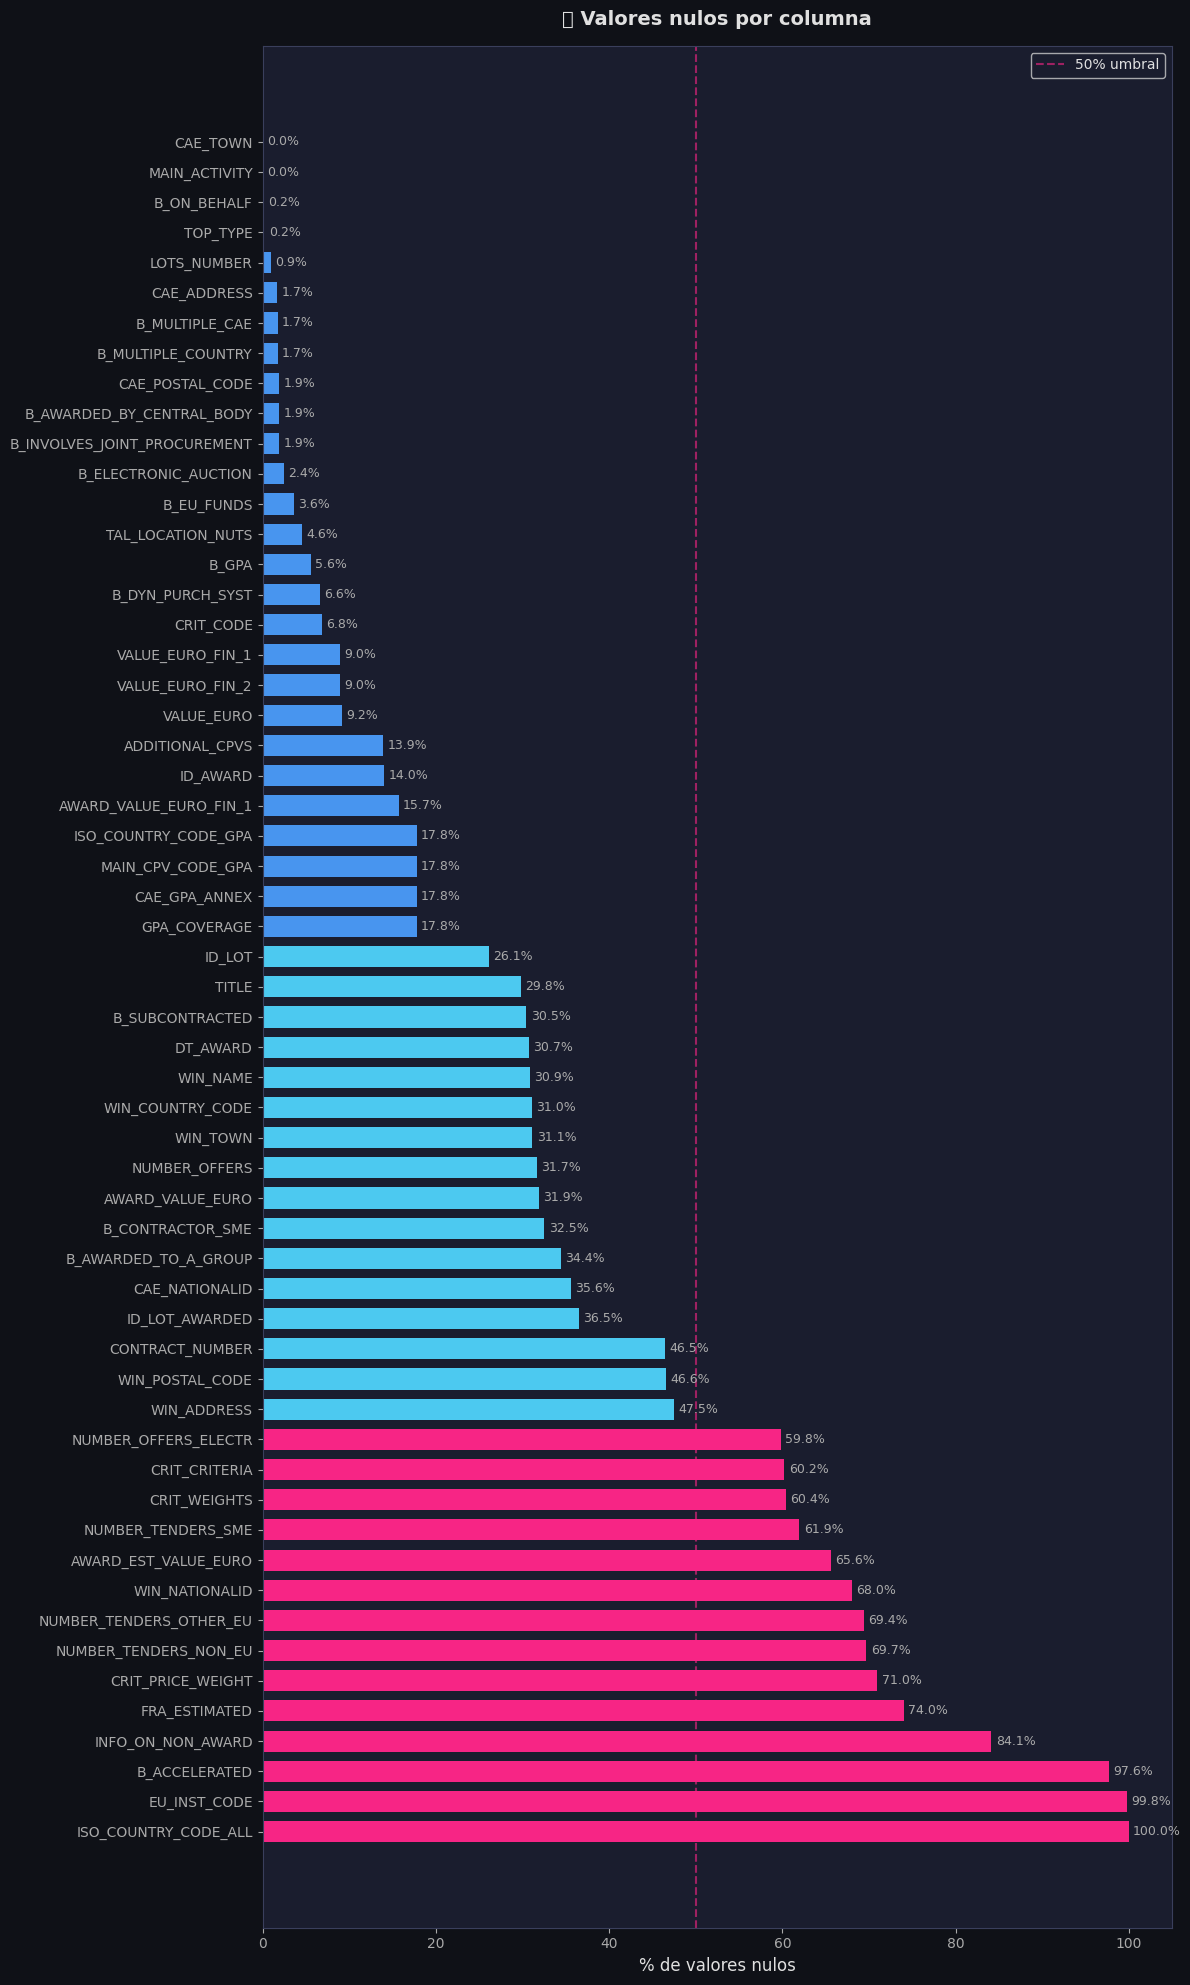


🔴 Columnas con >50% nulos: 14
🟡 Columnas con >20% nulos: 30
🟢 Columnas sin nulos: 18


In [5]:
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
null_df = null_pct[null_pct > 0].reset_index()
null_df.columns = ['Columna', 'Nulos (%)']

fig, ax = plt.subplots(figsize=(12, max(4, len(null_df) * 0.35)))
colors = ['#f72585' if x > 50 else '#4cc9f0' if x > 20 else '#4895ef' for x in null_df['Nulos (%)']]
bars = ax.barh(null_df['Columna'], null_df['Nulos (%)'], color=colors, edgecolor='none', height=0.7)
ax.set_xlabel('% de valores nulos', fontsize=12)
ax.set_title('📉 Valores nulos por columna', pad=15)
ax.axvline(50, color='#f72585', linestyle='--', alpha=0.6, label='50% umbral')
ax.legend()
for bar, val in zip(bars, null_df['Nulos (%)']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9, color='#aaaaaa')
plt.tight_layout()
plt.show()
print(f'\n🔴 Columnas con >50% nulos: {(null_pct > 50).sum()}')
print(f'🟡 Columnas con >20% nulos: {(null_pct > 20).sum()}')
print(f'🟢 Columnas sin nulos: {(null_pct == 0).sum()}')

## 3. 📅 Análisis temporal

In [6]:
# Detectar automáticamente columnas de fecha
date_candidates = [c for c in df.columns if any(k in c.lower() for k in ['date', 'fecha', 'year', 'dispatch', 'deadline', 'award'])]
print(f'Columnas de fecha candidatas: {date_candidates}')

# Parsear la primera columna de fecha encontrada
date_col = None
for col in date_candidates:
    try:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        if df[col].notna().sum() > len(df) * 0.5:
            date_col = col
            print(f'✅ Usando columna de fecha: {date_col}')
            break
    except:
        continue

if date_col:
    df['year'] = df[date_col].dt.year
    df['month'] = df[date_col].dt.month
    df['year_month'] = df[date_col].dt.to_period('M')
    print(f'Rango temporal: {df[date_col].min().date()} → {df[date_col].max().date()}')
else:
    # Si no hay fecha, buscar columna de año
    year_cols = [c for c in df.columns if 'year' in c.lower()]
    if year_cols:
        date_col = year_cols[0]
        df['year'] = pd.to_numeric(df[date_col], errors='coerce')
        print(f'⚠️ Usando columna de año: {date_col}')

Columnas de fecha candidatas: ['YEAR', 'DT_DISPATCH', 'B_AWARDED_BY_CENTRAL_BODY', 'NUMBER_AWARDS', 'ID_AWARD', 'ID_LOT_AWARDED', 'INFO_ON_NON_AWARD', 'B_AWARDED_TO_A_GROUP', 'AWARD_EST_VALUE_EURO', 'AWARD_VALUE_EURO', 'AWARD_VALUE_EURO_FIN_1', 'DT_AWARD']
✅ Usando columna de fecha: YEAR
Rango temporal: 1970-01-01 → 1970-01-01


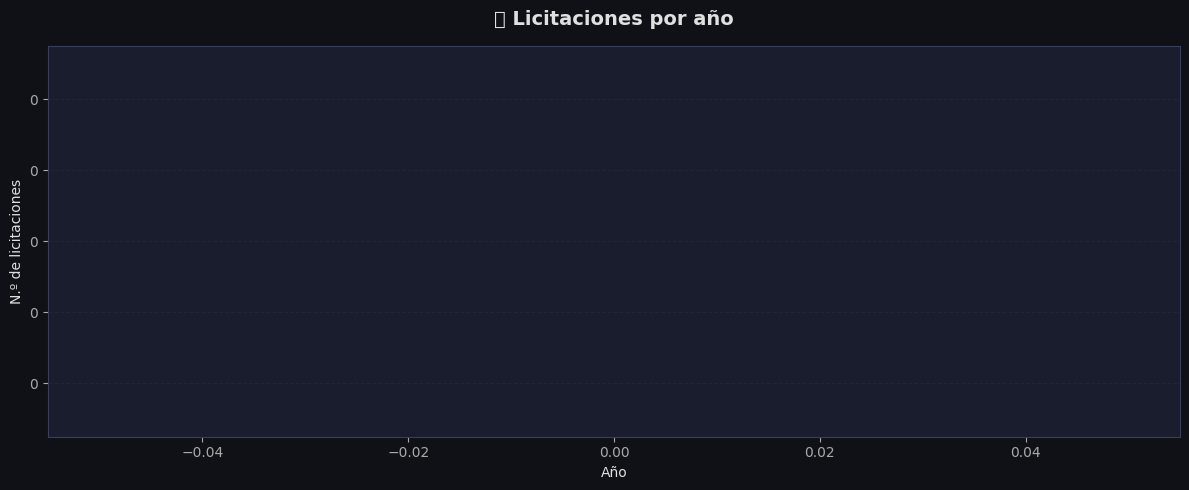

In [7]:
if 'year' in df.columns:
    yearly = df.groupby('year').size().reset_index(name='count')
    yearly = yearly[yearly['year'].between(2017, 2024)]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.fill_between(yearly['year'], yearly['count'], alpha=0.3, color='#4cc9f0')
    ax.plot(yearly['year'], yearly['count'], color='#4cc9f0', linewidth=2.5, marker='o',
            markersize=8, markerfacecolor='#f72585', markeredgewidth=2, markeredgecolor='#4cc9f0')
    for _, row in yearly.iterrows():
        ax.annotate(f"{int(row['count']):,}",
                    (row['year'], row['count']),
                    textcoords='offset points', xytext=(0, 12),
                    ha='center', fontsize=10, color='#e0e0e0')
    ax.set_title('📈 Licitaciones por año', pad=15)
    ax.set_xlabel('Año')
    ax.set_ylabel('N.º de licitaciones')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.grid(True, axis='y')
    plt.tight_layout()
    plt.show()

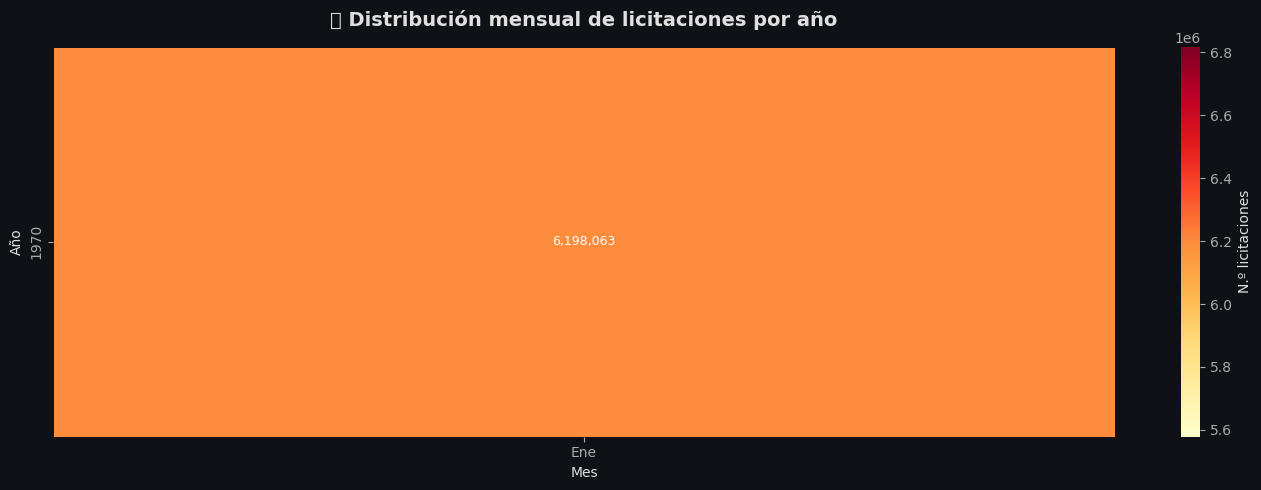

In [8]:
# Heatmap mensual si hay datos de mes
if 'month' in df.columns and 'year' in df.columns:
    pivot = df.groupby(['year', 'month']).size().unstack(fill_value=0)
    pivot.index = pivot.index.astype(int)
    pivot.columns = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'][:len(pivot.columns)]

    fig, ax = plt.subplots(figsize=(14, 5))
    sns.heatmap(pivot, cmap='YlOrRd', ax=ax, linewidths=0.5, linecolor='#0f1117',
                fmt=',d', annot=True, annot_kws={'size': 9},
                cbar_kws={'label': 'N.º licitaciones'})
    ax.set_title('🗓️ Distribución mensual de licitaciones por año', pad=15)
    ax.set_ylabel('Año')
    ax.set_xlabel('Mes')
    plt.tight_layout()
    plt.show()

## 4. 🌍 Análisis geográfico (por país)

Columna de país detectada: CAE_NATIONALID


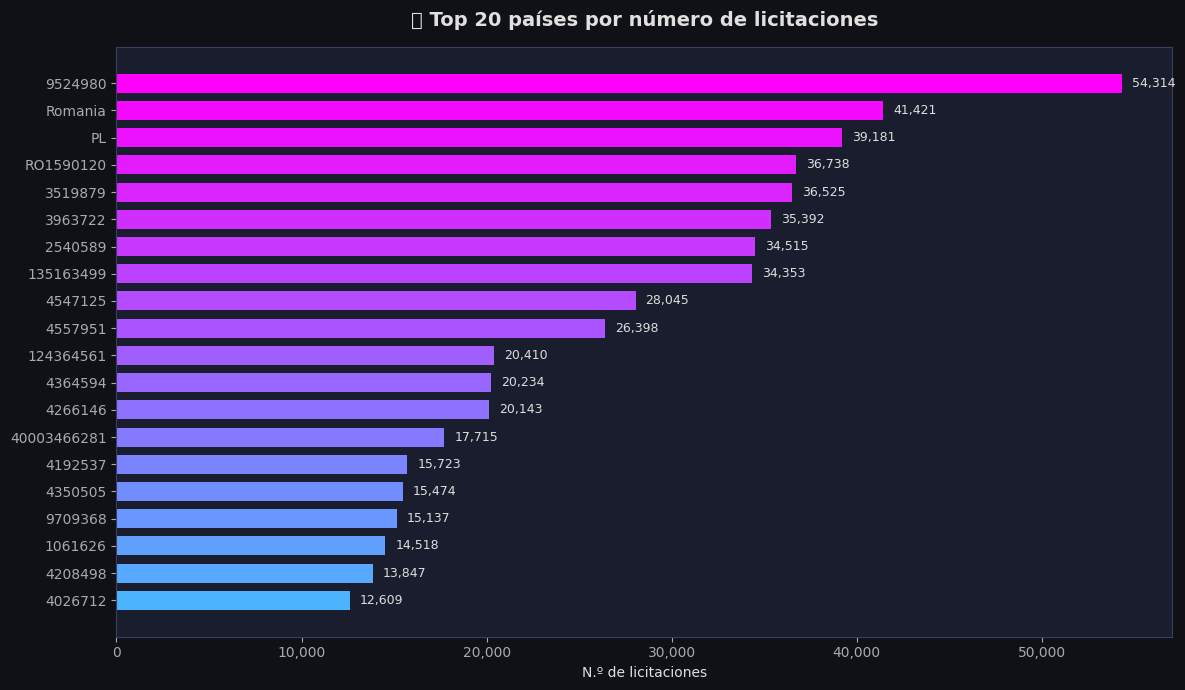

In [9]:
# Detectar columna de país
country_col = next((c for c in df.columns if any(k in c.lower() for k in ['country', 'pais', 'iso', 'nation'])), None)
print(f'Columna de país detectada: {country_col}')

if country_col:
    top_countries = df[country_col].value_counts().head(20).reset_index()
    top_countries.columns = ['País', 'Licitaciones']

    fig, ax = plt.subplots(figsize=(12, 7))
    gradient = plt.cm.cool(np.linspace(0.3, 1, len(top_countries)))
    bars = ax.barh(top_countries['País'][::-1], top_countries['Licitaciones'][::-1],
                   color=gradient, edgecolor='none', height=0.7)
    ax.set_title('🌍 Top 20 países por número de licitaciones', pad=15)
    ax.set_xlabel('N.º de licitaciones')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    for bar, val in zip(bars, top_countries['Licitaciones'][::-1]):
        ax.text(val + top_countries['Licitaciones'].max() * 0.01,
                bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=9, color='#dddddd')
    plt.tight_layout()
    plt.show()

In [10]:
# Mapa coroplético interactivo
if country_col:
    country_counts = df[country_col].value_counts().reset_index()
    country_counts.columns = ['iso_alpha', 'count']

    fig = px.choropleth(
        country_counts,
        locations='iso_alpha',
        color='count',
        color_continuous_scale='Viridis',
        scope='europe',
        title='🗺️ Licitaciones por país (2018–2023)',
        labels={'count': 'N.º licitaciones'}
    )
    fig.update_layout(
        paper_bgcolor='#0f1117',
        plot_bgcolor='#0f1117',
        font_color='#e0e0e0',
        geo=dict(bgcolor='#1a1d2e', lakecolor='#1a1d2e', landcolor='#2a2d3e',
                 showframe=False, showcoastlines=True, coastlinecolor='#3a3f5c')
    )
    fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

## 5. 💶 Análisis de valores de contrato

Columna de valor detectada: B_AWARDED_BY_CENTRAL_BODY


ValueError: Dimensions of labels and X must be compatible

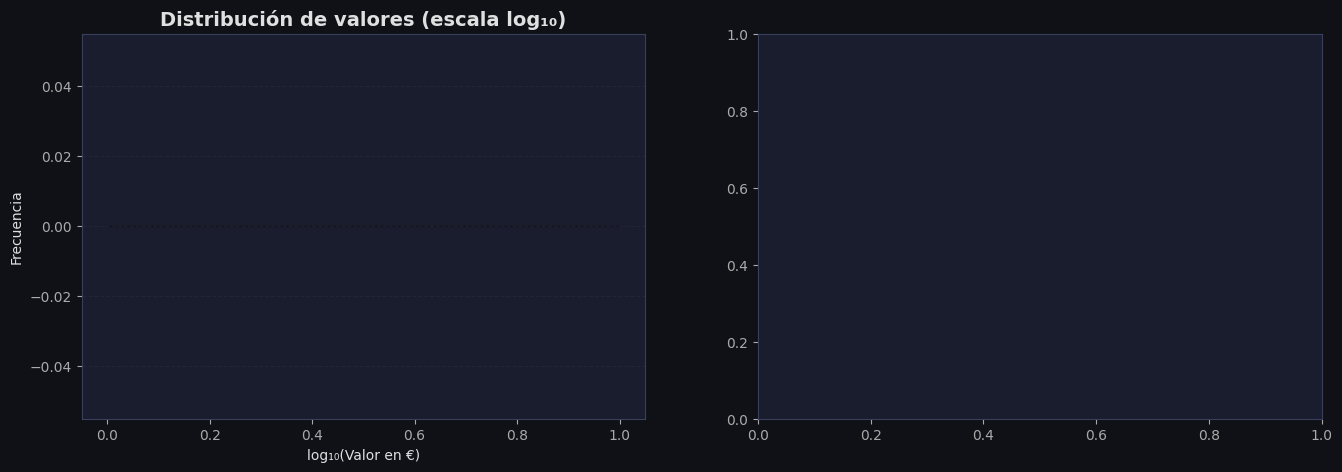

In [11]:
# Detectar columna de valor/importe
value_col = next((c for c in df.columns if any(k in c.lower() for k in
    ['value', 'amount', 'price', 'cost', 'euro', 'importe', 'valor', 'award'])), None)
print(f'Columna de valor detectada: {value_col}')

if value_col:
    df[value_col] = pd.to_numeric(df[value_col], errors='coerce')
    vals = df[value_col].dropna()
    vals_clean = vals[(vals > 0) & (vals < vals.quantile(0.999))]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Histograma log
    axes[0].hist(np.log10(vals_clean + 1), bins=60, color='#4cc9f0', edgecolor='#0f1117', alpha=0.85)
    axes[0].set_title('Distribución de valores (escala log₁₀)')
    axes[0].set_xlabel('log₁₀(Valor en €)')
    axes[0].set_ylabel('Frecuencia')
    axes[0].grid(True, axis='y')

    # Boxplot por año
    if 'year' in df.columns:
        df_box = df[[value_col, 'year']].dropna()
        df_box = df_box[(df_box[value_col] > 0) & (df_box['year'].between(2018, 2023))]
        years_sorted = sorted(df_box['year'].unique())
        data_by_year = [np.log10(df_box[df_box['year']==y][value_col] + 1) for y in years_sorted]
        bp = axes[1].boxplot(data_by_year, labels=[str(int(y)) for y in years_sorted],
                             patch_artist=True, notch=True)
        colors_box = plt.cm.cool(np.linspace(0.3, 1, len(years_sorted)))
        for patch, color in zip(bp['boxes'], colors_box):
            patch.set_facecolor(color)
            patch.set_alpha(0.8)
        for median in bp['medians']:
            median.set_color('#f72585')
            median.set_linewidth(2)
        axes[1].set_title('Distribución de valores por año')
        axes[1].set_xlabel('Año')
        axes[1].set_ylabel('log₁₀(Valor en €)')
        axes[1].grid(True, axis='y')

    plt.suptitle('💶 Análisis de Valores de Contrato', fontsize=15, y=1.02)
    plt.tight_layout()
    plt.show()

    # Estadísticas clave
    print('\n📊 Estadísticas de valor de contrato:')
    stats = {
        'Contratos con valor': f'{len(vals_clean):,}',
        'Mediana': f'€{vals_clean.median():,.0f}',
        'Media': f'€{vals_clean.mean():,.0f}',
        'Total acumulado': f'€{vals_clean.sum():,.0f}',
        'Máximo': f'€{vals_clean.max():,.0f}'
    }
    for k, v in stats.items():
        print(f'  {k}: {v}')

## 6. 🏷️ Análisis por tipo de contrato / procedimiento

In [ ]:
# Detectar columna de tipo
type_cols = [c for c in df.columns if any(k in c.lower() for k in
    ['type', 'procedure', 'category', 'cpv', 'kind', 'contract_type', 'award_criteria'])]
print(f'Columnas de tipo candidatas: {type_cols}')

for type_col in type_cols[:3]:  # Analizar hasta 3
    vc = df[type_col].value_counts().head(10)
    if len(vc) < 2:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Barras
    colors_type = plt.cm.cool(np.linspace(0.2, 1, len(vc)))
    axes[0].barh(vc.index[::-1], vc.values[::-1], color=colors_type[::-1], edgecolor='none', height=0.7)
    axes[0].set_title(f'Top categorías: {type_col}')
    axes[0].set_xlabel('N.º de licitaciones')
    axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    # Donut
    top5 = df[type_col].value_counts().head(5)
    other = df[type_col].value_counts().iloc[5:].sum()
    if other > 0:
        top5['Otros'] = other
    wedges, texts, autotexts = axes[1].pie(
        top5.values, labels=top5.index, autopct='%1.1f%%',
        colors=plt.cm.cool(np.linspace(0.1, 1, len(top5))),
        startangle=90, pctdistance=0.8,
        wedgeprops=dict(width=0.5, edgecolor='#0f1117', linewidth=2)
    )
    for text in autotexts:
        text.set_fontsize(9)
        text.set_color('white')
    axes[1].set_title(f'Proporción: {type_col}')

    plt.tight_layout()
    plt.show()

## 7. 🔗 Correlaciones y relaciones entre variables

In [ ]:
# Correlación entre numéricas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Columnas numéricas: {num_cols}')

if len(num_cols) >= 2:
    corr = df[num_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    fig, ax = plt.subplots(figsize=(max(8, len(num_cols)), max(6, len(num_cols)-1)))
    sns.heatmap(corr, mask=mask, cmap='coolwarm', vmin=-1, vmax=1, center=0,
                annot=True, fmt='.2f', ax=ax, linewidths=0.5,
                cbar_kws={'label': 'Correlación de Pearson'},
                annot_kws={'size': 10})
    ax.set_title('🔗 Matriz de correlación entre variables numéricas', pad=15)
    plt.tight_layout()
    plt.show()

## 8. 📊 Evolución por país y año (Top 5)

In [ ]:
if country_col and 'year' in df.columns:
    top5_countries = df[country_col].value_counts().head(5).index.tolist()
    df_top5 = df[df[country_col].isin(top5_countries) & df['year'].between(2018, 2023)]
    evolution = df_top5.groupby(['year', country_col]).size().reset_index(name='count')

    fig = px.line(
        evolution, x='year', y='count', color=country_col,
        markers=True,
        title='📈 Evolución de licitaciones — Top 5 países (2018–2023)',
        labels={'count': 'N.º de licitaciones', 'year': 'Año', country_col: 'País'},
        color_discrete_sequence=px.colors.qualitative.Bold
    )
    fig.update_layout(
        paper_bgcolor='#0f1117', plot_bgcolor='#1a1d2e',
        font_color='#e0e0e0',
        xaxis=dict(gridcolor='#2a2d3e'),
        yaxis=dict(gridcolor='#2a2d3e'),
        legend=dict(bgcolor='#1a1d2e', bordercolor='#3a3f5c')
    )
    fig.update_traces(line_width=2.5, marker_size=8)
    fig.show()

## 9. 📋 Resumen ejecutivo

In [ ]:
print('=' * 60)
print('        📋 RESUMEN EJECUTIVO DEL ANÁLISIS')
print('=' * 60)

print(f'\n📦 Dataset: Tenders Electronic Daily 2018–2023')
print(f'   • Registros totales: {len(df):,}')
print(f'   • Variables: {df.shape[1]}')
print(f'   • Duplicados: {df.duplicated().sum():,}')
print(f'   • Columnas sin nulos: {(df.isnull().sum() == 0).sum()}')

if 'year' in df.columns:
    yr_counts = df.groupby('year').size()
    print(f'\n📅 Temporal:')
    for yr, cnt in yr_counts.items():
        if 2018 <= int(yr) <= 2023:
            print(f'   • {int(yr)}: {cnt:,} licitaciones')

if country_col:
    top3 = df[country_col].value_counts().head(3)
    print(f'\n🌍 Top 3 países:')
    for country, cnt in top3.items():
        pct = cnt/len(df)*100
        print(f'   • {country}: {cnt:,} ({pct:.1f}%)')

if value_col and df[value_col].notna().sum() > 0:
    vals_summary = df[value_col].dropna()
    vals_summary = vals_summary[vals_summary > 0]
    print(f'\n💶 Valores de contrato:')
    print(f'   • Mediana: €{vals_summary.median():,.0f}')
    print(f'   • Media: €{vals_summary.mean():,.0f}')
    print(f'   • Volumen total: €{vals_summary.sum():,.0f}')

print('\n' + '=' * 60)
print('✅ Análisis completado exitosamente')
print('=' * 60)